In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline

In [2]:
df = pd.read_csv('exchange_rate.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df = df.asfreq('D')
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [3]:
df.shape

(7588, 1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Freq: D
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [5]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [6]:
df.isnull().sum()

Ex_rate    0
dtype: int64

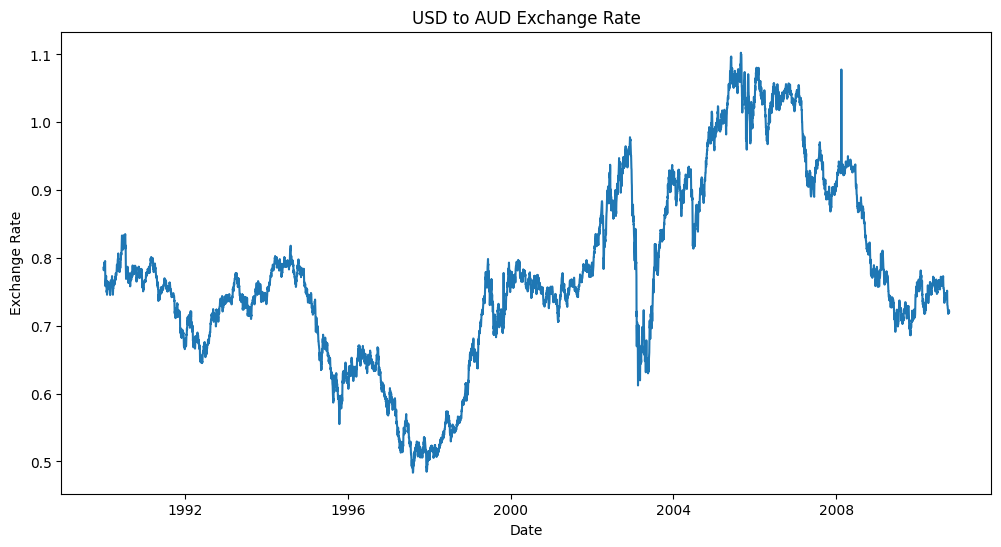

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'])
plt.title('USD to AUD Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

In [8]:
train_data = df['Ex_rate'].iloc[:-30]
test_data = df['Ex_rate'].iloc[-30:]
train_data.shape, test_data.shape

((7558,), (30,))

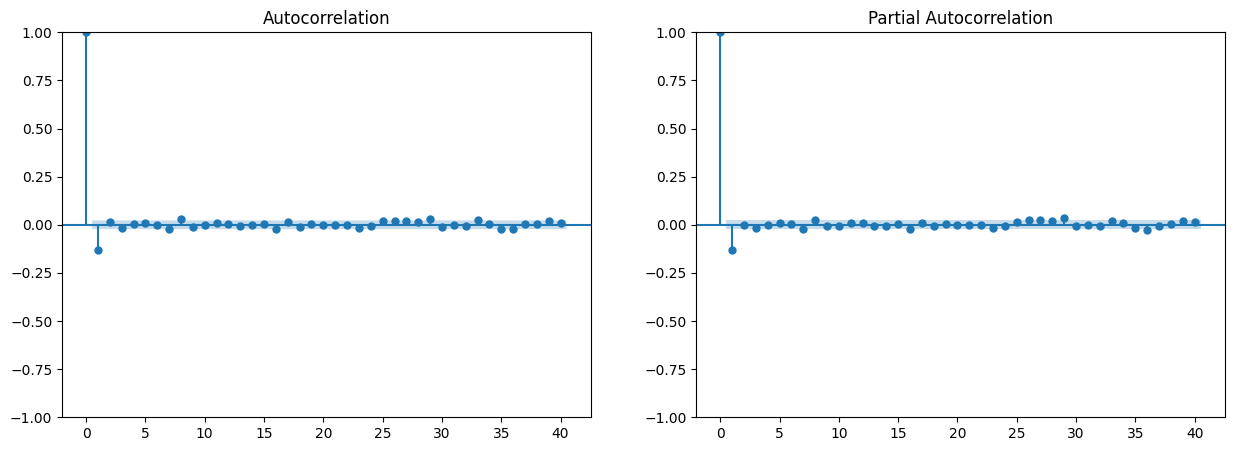

In [9]:
diff_data = train_data.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(diff_data, ax=axes[0], lags=40)
plot_pacf(diff_data, ax=axes[1], lags=40)
plt.show()

In [10]:
arima = ARIMA(train_data, order=(1, 1, 1))
arima_fit = arima.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Thu, 18 Jun 2026   AIC                         -55862.942
Time:                        19:03:27   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.764      0.0

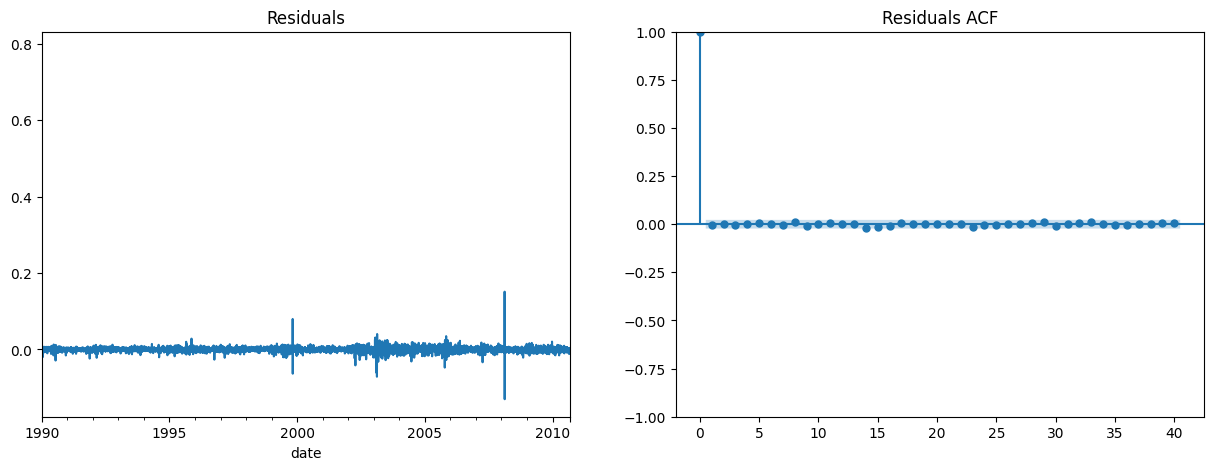

In [11]:
residuals = arima_fit.resid
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
residuals.plot(title='Residuals', ax=axes[0])
plot_acf(residuals, ax=axes[1], lags=40, title='Residuals ACF')
plt.show()

In [12]:
arima_forecast = arima_fit.forecast(steps=30)

In [13]:
es = ExponentialSmoothing(train_data, trend='add', seasonal=None)
es_fit = es.fit()
es_forecast = es_fit.forecast(steps=30)

In [14]:
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100

mae_arima = mean_absolute_error(test_data, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_data, arima_forecast))
mape_arima_val = mape(test_data.values, arima_forecast.values)

mae_es = mean_absolute_error(test_data, es_forecast)
rmse_es = np.sqrt(mean_squared_error(test_data, es_forecast))
mape_es_val = mape(test_data.values, es_forecast.values)

comp_df = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae_arima, mae_es],
    'RMSE': [rmse_arima, rmse_es],
    'MAPE (%)': [mape_arima_val, mape_es_val]
})
print(comp_df)

                   Model       MAE      RMSE  MAPE (%)
0                  ARIMA  0.013495  0.016632  1.863221
1  Exponential Smoothing  0.013423  0.016496  1.853156


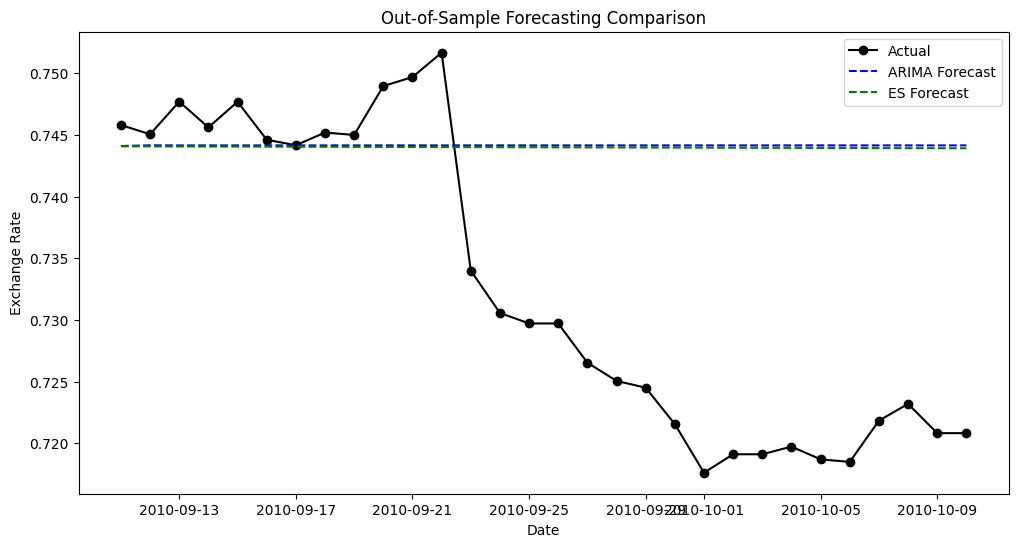

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual', color='black', marker='o')
plt.plot(test_data.index, arima_forecast.values, label='ARIMA Forecast', color='blue', linestyle='--')
plt.plot(test_data.index, es_forecast.values, label='ES Forecast', color='green', linestyle='--')
plt.title('Out-of-Sample Forecasting Comparison')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()